# 14_损失函数-交叉熵损失

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本节，咱们来聊聊交叉熵损失\~

先回顾一下「损失函数」这个概念。

- **损失函数**就是一个用来衡量模型预测结果和真实答案差距的工具。
- 换句话说，它告诉你“模型这次预测错得有多严重”。
- 损失越小，说明模型预测得越好；损失越大，说明模型预测得越差。

### 交叉熵损失

交叉熵损失主要用在**分类问题**，比如判断图片是猫还是狗。

- 模型会给出每个类别的概率，比如模型说：

  - 猫：0.8
  - 狗：0.2
- 真实标签是“猫”。

那么，交叉熵损失就用来衡量“模型预测的概率分布”和“真实标签的分布”之间差别有多大。

- 真实标签其实可以看成是“猫”的概率是1，“狗”的概率是0。
- 交叉熵衡量模型预测的概率跟真实标签的概率有多接近。
- 如果模型给“猫”的概率很大，交叉熵损失就小；
- 如果模型给“猫”的概率很小，交叉熵损失就大。

## 数学原理

### 1. 交叉熵的数学定义

假设我们有两个概率分布：

- 真实分布 $p$
- 预测分布 $q$

交叉熵（Cross-Entropy）定义为：


$$
H(p, q) = - \sum_{i} p(i) \log q(i)
$$


意思是：对所有类别 $i$，把真实概率 $p(i)$ 乘以预测概率 $q(i)$ 的对数，再求和取负。

### 2. 为什么是负号和对数？

- 对数（log）让概率乘积变成加法，方便计算和求导。
- 负号是因为对数函数对小概率是负数，负号让损失是正的（越差越大）。

### 3. 真实标签和预测概率的关系

在分类问题中，真实标签一般用**one-hot编码**表示：

- 真实类别 $j$ 的 $p(j) = 1$
- 其他类别 $p(i) = 0$

所以交叉熵变成只关心真实类别的预测概率：


$$
H(p, q) = - \log q(j)
$$


也就是说，损失函数只看模型给正确类别的概率是多少。

## 交叉熵损失核心内容

假设：

- 总共有 $C$ 个类别
- 样本真实标签用one-hot向量 $y = (y_1, y_2, ..., y_C)$，其中只有一个位置是1，其余是0
- 模型预测的概率是 $\hat{y} = (\hat{y}_1, \hat{y}_2, ..., \hat{y}_C)$，所有概率和为1

交叉熵损失定义为：


$$
L = - \sum_{i=1}^C y_i \log(\hat{y}_i)
$$


因为 $y_i$ 只有真实类别是1，其他是0，公式等价于：


$$
L = - \log(\hat{y}_{\text{真实类别}})
$$


为什么交叉熵能帮模型学习？

- 当模型预测正确类别的概率 $\hat{y}_{\text{真实类别}}$ 越大，$- \log(\hat{y}_{\text{真实类别}})$ 越小，损失越小。
- 当概率越小，损失越大，模型会受到更大惩罚，促使调整参数，提高正确类别概率。
- 这个机制让模型不断优化参数，变得更准确。

### 一个简单的举例

假设有3个类别（猫、狗、鸟），真实类别是“狗”，即：


$$
y = (0, 1, 0)
$$


模型预测概率：

- 猫：0.1
- 狗：0.7
- 鸟：0.2

计算交叉熵损失：


$$
L = - (0 \cdot \log 0.1 + 1 \cdot \log 0.7 + 0 \cdot \log 0.2) = - \log 0.7 \approx 0.357
$$


如果模型预测错误，比如狗的概率是0.1：


$$
L = - \log 0.1 = 2.302
$$


损失更大，惩罚更严重。

### 交叉熵损失的算法流程

1. **模型输出概率向量** $\hat{y}$（通常是用Softmax函数把神经网络的原始输出转化成概率分布）
2. **准备真实标签** $y$ （用one-hot编码）
3. **计算交叉熵损失**：


$$
L = - \sum_{i=1}^C y_i \log(\hat{y}_i)
$$


1. **根据损失调整模型参数**，使用梯度下降等方法，反向传播计算损失对参数的梯度，更新参数。
2. **重复以上步骤**，直到损失足够小，模型表现足够好。

## 完整案例

我们构造一个人工二分类数据集（两类数据点分布在二维空间），训练一个简单的线性分类器。模型使用 Softmax 层输出概率，再用交叉熵作为损失函数进行训练优化。

测试集损失: 0.2998, 测试集准确率: 0.8950


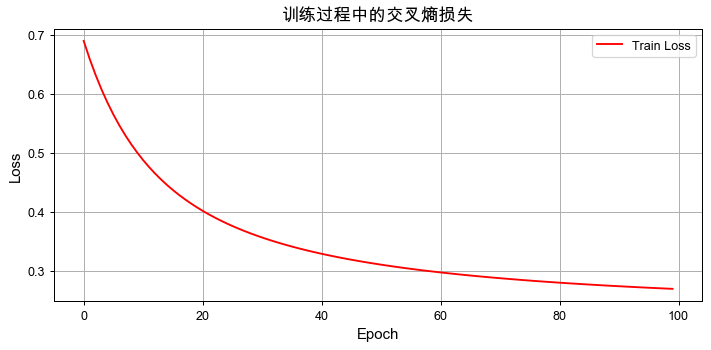

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 生成一个二分类数据集
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, n_classes=2, random_state=42)

# 标准化输入特征
X = (X - X.mean(axis=0)) / X.std(axis=0)

# 将标签转为 one-hot 编码
y_onehot = np.zeros((y.size, 2))
y_onehot[np.arange(y.size), y] = 1

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 初始化参数
np.random.seed(42)
W = np.random.randn(2, 2) * 0.01  # 权重矩阵：2个特征 -> 2个类
b = np.zeros((1, 2))              # 偏置

lr = 0.1         # 学习率
epochs = 100     # 训练轮数

# Softmax函数
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # 数值稳定性处理
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 损失记录
loss_history = []
acc_history = []

# 训练过程
for epoch in range(1, epochs + 1):
    # 前向传播
    logits = np.dot(X_train, W) + b
    probs = softmax(logits)

    # 交叉熵损失
    loss = -np.mean(np.sum(y_train * np.log(probs + 1e-15), axis=1))

    # 准确率
    preds = np.argmax(probs, axis=1)
    true = np.argmax(y_train, axis=1)
    acc = np.mean(preds == true)

    # 反向传播（Softmax + 交叉熵合并梯度）
    grad_logits = (probs - y_train) / y_train.shape[0]
    dW = np.dot(X_train.T, grad_logits)
    db = np.sum(grad_logits, axis=0, keepdims=True)

    # 参数更新
    W -= lr * dW
    b -= lr * db

    # 存储记录
    loss_history.append(loss)
    acc_history.append(acc)

# 测试集评估
logits_test = np.dot(X_test, W) + b
probs_test = softmax(logits_test)
test_loss = -np.mean(np.sum(y_test * np.log(probs_test + 1e-15), axis=1))
test_preds = np.argmax(probs_test, axis=1)
test_true = np.argmax(y_test, axis=1)
test_acc = np.mean(test_preds == test_true)

print(f"测试集损失: {test_loss:.4f}, 测试集准确率: {test_acc:.4f}")

# 可视化部分
# 损失曲线
plt.figure(figsize=(8,4))
plt.plot(loss_history, label='Train Loss', color='red')
plt.title("训练过程中的交叉熵损失", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

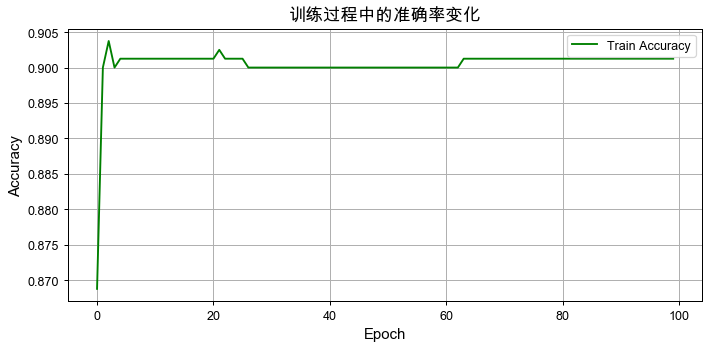

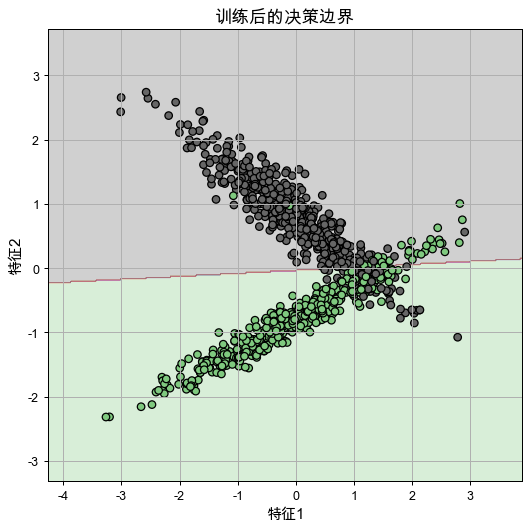

In [3]:
# 准确率曲线
plt.figure(figsize=(8,4))
plt.plot(acc_history, label='Train Accuracy', color='green')
plt.title("训练过程中的准确率变化", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 决策边界可视化
h = 0.02
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = softmax(np.dot(grid, W) + b)
Z = np.argmax(Z, axis=1).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Accent')
plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y_onehot, axis=1), edgecolors='k', cmap='Accent')
plt.title("训练后的决策边界", fontsize=14)
plt.xlabel("特征1", fontsize=12)
plt.ylabel("特征2", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

1. 训练损失下降曲线（红色）

![原文参考图，当前结果见代码输出](attachments/img_005.png)

1. 准确率上升曲线

![原文参考图，当前结果见代码输出](attachments/img_006.png)

1. 模型的分类决策边界

![原文参考图，当前结果见代码输出](attachments/img_007.png)

## 模型分析

### 交叉熵损失的优缺点

**优点**：

1. **凸性良好**（对线性模型而言）：交叉熵相对于逻辑回归的参数空间是凸的，保证了全局最优解。
2. **梯度表达式简洁**：Softmax+Cross-Entropy 的梯度可以合并为 `probs - y_onehot`，计算简单且高效。
3. **数值稳定性**：对小概率惩罚更大，能有效加快训练收敛。
4. **与概率解释契合**：直接以概率分布为输出，符合分类任务的本质需求。

**缺点**：

1. **对离群点敏感**：如果模型非常置信地预测错了（给错类的概率接近 0），则 `-log(p)` 会非常大，可能导致梯度爆炸。
2. **对类不平衡无天然补偿**：在类别分布严重不平衡时，需要额外设计加权交叉熵或采样策略。
3. **对模型输出要求高**：需要先通过 Softmax 归一化得到概率，否则无法正确计算。

### 与相似算法的对比

| 算法 | 损失定义 | 适用场景 | 优缺点简述 |
|-|-|-|-|
| **交叉熵损失（Cross-Entropy）** | $-\sum_i y_i \log \hat y_i$ | 二分类/多分类概率输出场景 | 梯度简洁，收敛快；对小概率敏感，需要注意数值稳定性。 |
| **均方误差（MSE）** | $\frac{1}{N}\sum_i (\hat y_i - y_i)^2$ | 回归，也可用于分类（不推荐） | 平滑但对概率偏差不够敏感，收敛慢，不适合概率预测。 |
| **对比损失（Hinge Loss）** | $\sum_i \max(0, 1 - y_i f(x_i))$ | 支持向量机等最大间隔分类 | 强调边界样本，对概率不建模，非概率输出，梯度不连续。 |
| **KL 散度（Kullback-Leibler）** | $\sum_i y_i \log \frac{y_i}{\hat y_i}$ | 分布对齐、生成模型 | 与交叉熵只差一个常数项，更强调分布间差异。 |
| **焦点损失（Focal Loss）** | $-\sum_i (1 - \hat y_i)^\gamma y_i \log \hat y_i$ | 类不平衡的目标检测与分类 | 为困难样本加大权重，抑制易分类样本的梯度贡献。 |

### 何时优选交叉熵损失，何时考虑其他算法

1. **优选交叉熵的场景**

   - 任务本质是**分类**，且需要输出概率分布（例如多分类、目标检测中的分类分支）。
   - 数据集类别相对平衡，或可以通过加权交叉熵轻松处理少量不平衡。
   - 模型结构是神经网络、逻辑回归等能够对 Softmax+Cross-Entropy 自然支持的。
2. **考虑其他算法的场景**

   - **回归任务**：输出值是连续实数，用均方误差 (MSE) 或 MAE 更合适。
   - **类别极度不平衡**：可以尝试**焦点损失 (Focal Loss)**、加权交叉熵或过/欠采样策略。
   - **最大间隔需求**：对于需要“硬”边界（如 SVM）的场景，Hinge Loss 能更好地保证分类边界。
   - **生成模型**：若关注整个分布对齐，可能直接使用 KL 散度或 JS 散度。

## 总结

交叉熵损失是分类任务中最常用且效果良好的损失函数，尤其在概率输出模型中表现优越。它通过惩罚错误预测的高置信度，大幅提升模型训练的效率与判别力。但在处理极度不平衡数据或异常值时，其敏感性也可能带来训练不稳定的问题。